### Setup

In [1]:
import os

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm.auto import tqdm

In [2]:
batch_size          = 256
kernel_size         = 4

In [3]:
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[device]: ", device)

transform = transforms.ToTensor()
data_root = os.path.expanduser("~/.torch/data")

train_ds = datasets.CIFAR10(
    root=data_root,
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    drop_last=True,
)

xb, _ = next(iter(train_loader))
print("batch:", xb.shape)

[device]:  cuda
batch: torch.Size([256, 3, 32, 32])


### Model

In [4]:
class OneHiddenConvAE(nn.Module):
    def __init__(
        self,
        *,
        bottleneck_channels: int = 2,
        kernel_size: int = 3,
        train_stride: int = 1,
        infer_stride: int = None,
    ):
        super().__init__()
        if bottleneck_channels >= 3:
            raise ValueError("Autoencoder is underconstrained for CIFAR10")

        self.k = kernel_size
        self.p = 1
        self.train_stride = train_stride
        self.infer_stride = train_stride if infer_stride is None else infer_stride

        self.encoder      = nn.Conv2d(3, bottleneck_channels, kernel_size=self.k, stride=1, padding=self.p)
        self.decoder_bias = nn.Parameter(torch.zeros(3))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        s = self.train_stride if torch.is_grad_enabled() else self.infer_stride

        # Encoder
        z = F.relu(
            F.conv2d(
                x, 
                self.encoder.weight, 
                self.encoder.bias, 
                stride=s, 
                padding=self.p
            )
        )
        _, _, xh, xw = x.shape
        _, _, hz, wz = z.shape

        base_h = (hz - 1) * s - 2 * self.p + self.k
        base_w = (wz - 1) * s - 2 * self.p + self.k
        op = (xh - base_h, xw - base_w)

        # Decoder
        x_hat = F.conv_transpose2d(
            z,
            weight=self.encoder.weight,
            bias=self.decoder_bias,
            stride=s,
            padding=self.p,
            output_padding=op,
        )
        return torch.sigmoid(x_hat)

In [5]:
def train(model: nn.Module, loader: DataLoader, *, epochs: int = 10, lr: float = 1e-3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    epoch_bar = tqdm(range(epochs), desc="epochs", leave=True)
    for epoch in epoch_bar:
        model.train()
        total = 0.0
        n = 0

        batch_bar = tqdm(loader, desc=f"epoch {epoch + 1:02d}", leave=False)
        for xb, _ in batch_bar:
            xb = xb.to(device, non_blocking=True)
            x_hat = model(xb)
            loss = F.mse_loss(x_hat, xb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            bs = xb.size(0)
            total += loss.item() * bs
            n += bs

            batch_bar.set_postfix(loss=f"{loss.item():.4f}")

        epoch_loss = total / n
        losses.append(epoch_loss)
        epoch_bar.set_postfix(epoch_loss=f"{epoch_loss:.6f}")

    return losses

### Training

In [6]:
bottleneck_channels = 2
epochs              = 20
lr                  = 1e-3

m_stride1 = OneHiddenConvAE(
    bottleneck_channels=bottleneck_channels,
    kernel_size=kernel_size,
    train_stride=1,
    infer_stride=kernel_size,
)
m_strideK = OneHiddenConvAE(
    bottleneck_channels=bottleneck_channels,
    kernel_size=kernel_size,
    train_stride=kernel_size,
    infer_stride=1,
)

loss_stride1 = train(m_stride1, train_loader, epochs=epochs, lr=lr)
loss_strideK = train(m_strideK, train_loader, epochs=epochs, lr=lr)

loss_stride1[:3], loss_strideK[:3]

epochs:   0%|          | 0/20 [00:00<?, ?it/s]

epoch 01:   0%|          | 0/195 [00:00<?, ?it/s]

epoch 02:   0%|          | 0/195 [00:00<?, ?it/s]

epoch 03:   0%|          | 0/195 [00:00<?, ?it/s]

epoch 04:   0%|          | 0/195 [00:00<?, ?it/s]

...

epoch 17:   0%|          | 0/195 [00:00<?, ?it/s]

epoch 18:   0%|          | 0/195 [00:00<?, ?it/s]

epoch 19:   0%|          | 0/195 [00:00<?, ?it/s]

epoch 20:   0%|          | 0/195 [00:00<?, ?it/s]

([0.048639117849942966, 0.034108560723372, 0.021010557495248623],
 [0.05709445650378863, 0.04583554963270823, 0.03816624755660693])

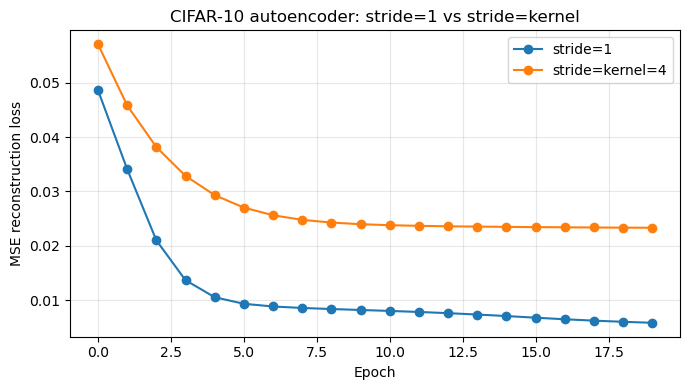

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(loss_stride1, marker="o", label="stride=1")
plt.plot(loss_strideK, marker="o", label=f"stride=kernel={kernel_size}")
plt.xlabel("Epoch")
plt.ylabel("MSE reconstruction loss")
plt.title("CIFAR-10 autoencoder: stride=1 vs stride=kernel")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

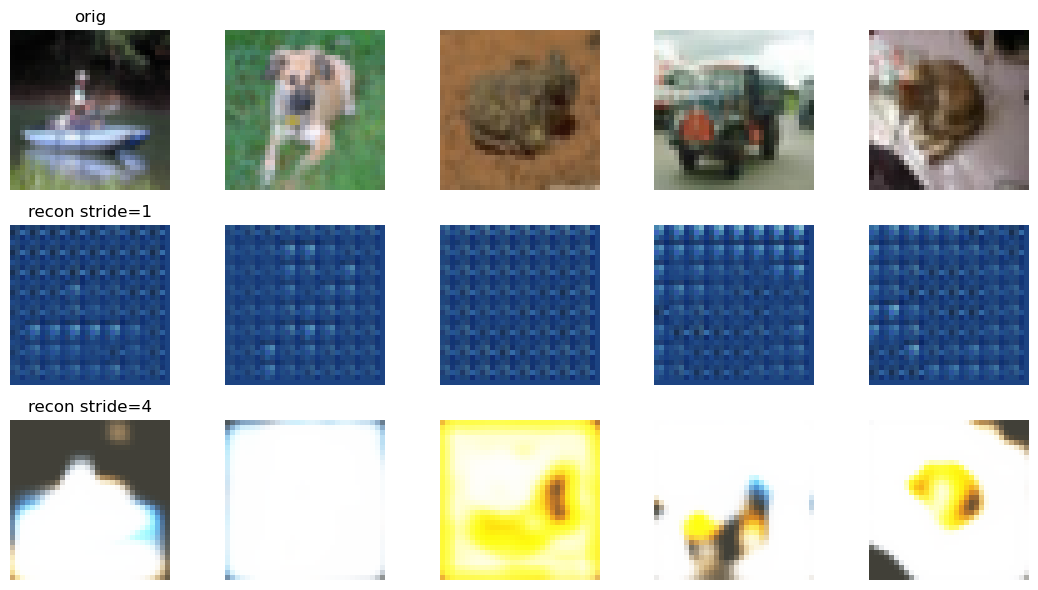

In [9]:
@torch.no_grad()
def show_random_recons(model_a, model_b, loader: DataLoader, *, n: int = 5):
    model_a.eval()
    model_b.eval()

    xb, _ = next(iter(loader))
    idx = torch.randperm(xb.size(0))[:n]
    x0 = xb[idx].to(device)

    x1 = model_a(x0).clamp(0, 1).cpu()
    xk = model_b(x0).clamp(0, 1).cpu()
    x0 = x0.cpu()

    plt.figure(figsize=(2.2 * n, 6))
    for i in range(n):
        plt.subplot(3, n, i + 1)
        plt.imshow(x0[i].permute(1, 2, 0))
        plt.axis("off")
        if i == 0:
            plt.title("orig")

        plt.subplot(3, n, n + i + 1)
        plt.imshow(x1[i].permute(1, 2, 0))
        plt.axis("off")
        if i == 0:
            plt.title("recon stride=1")

        plt.subplot(3, n, 2 * n + i + 1)
        plt.imshow(xk[i].permute(1, 2, 0))
        plt.axis("off")
        if i == 0:
            plt.title(f"recon stride={kernel_size}")

    plt.tight_layout()
    plt.show()


show_random_recons(m_stride1, m_strideK, train_loader, n=5)
